In [1]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
import numpy as np
import pandas as pd
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_samples
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import os
os.getcwd()

'c:\\Users\\japar\\OneDrive\\Documentos\\Repositorio AstroML\\AstroML_202610\\Lab4'

In [2]:
df = pd.read_csv("dataset_porcionado.csv").dropna(subset='pmra') # full gaia sample for one cluster
df = df.dropna(subset=['ra', 'dec', 'pmra','pmdec','parallax','bp_rp','phot_g_mean_mag'])
df.info(), df.columns

<class 'pandas.DataFrame'>
Index: 342356 entries, 0 to 365869
Data columns (total 29 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Unnamed: 0.1               342356 non-null  int64  
 1   Unnamed: 0                 342356 non-null  int64  
 2   source_id                  342356 non-null  int64  
 3   ra                         342356 non-null  float64
 4   dec                        342356 non-null  float64
 5   parallax                   342356 non-null  float64
 6   pmra                       342356 non-null  float64
 7   pmdec                      342356 non-null  float64
 8   ruwe                       342356 non-null  float64
 9   phot_g_mean_mag            342356 non-null  float64
 10  bp_rp                      342356 non-null  float64
 11  radial_velocity            164635 non-null  float64
 12  ra_error                   342356 non-null  float64
 13  dec_error                  342356 non-null  f

(None,
 Index(['Unnamed: 0.1', 'Unnamed: 0', 'source_id', 'ra', 'dec', 'parallax',
        'pmra', 'pmdec', 'ruwe', 'phot_g_mean_mag', 'bp_rp', 'radial_velocity',
        'ra_error', 'dec_error', 'pmra_error', 'pmdec_error', 'parallax_error',
        'visibility_periods_used', 'phot_bp_mean_mag', 'phot_rp_mean_mag',
        'nu_eff_used_in_astrometry', 'pseudocolour', 'ecl_lat',
        'astrometric_params_solved', 'zp', 'fidelity_v2', 'parallax_',
        'relative_error', 'cell_id'],
       dtype='str'))

In [3]:

# features derivadas
df["dist_pc"] = 1000 / df["parallax"]
df["parallax_over_error"] = df["parallax_error"] / df["parallax"]

# filtro global (opcional pero recomendable)
df = df[df["parallax_over_error"] <= 0.1]

print("Total estrellas:", len(df))
print("Total estrellas inicial:", len(df))
print("Índices únicos:", df.index.nunique())

Total estrellas: 342356
Total estrellas inicial: 342356
Índices únicos: 342356


In [4]:
clustering_on = ['pmra','pmdec','dist_pc']


total_input = 0
total_processed = 0
unique_ids = set()

results = []

  0%|          | 0/64 [00:00<?, ?it/s]


Cell 1
N estrellas: 1461
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 2
N estrellas: 3967
N clusters encontrados: 2
[TAMAÑO] Cluster 0 eliminado | N=1600 | Δd=44.61 pc


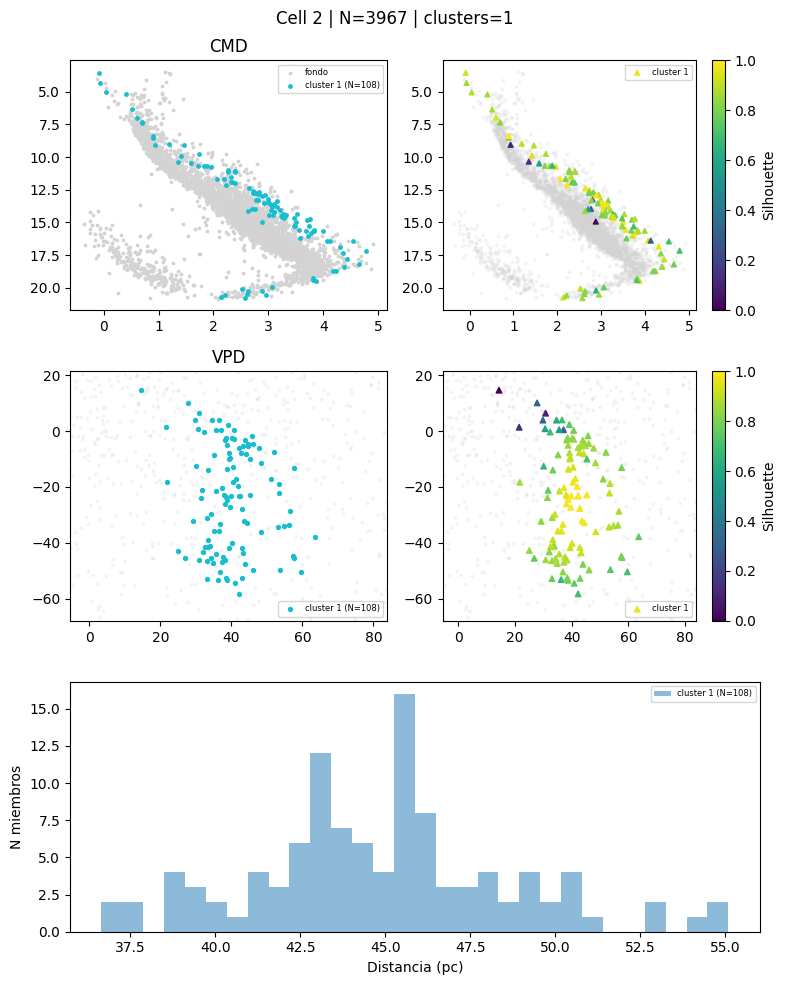

  3%|▎         | 2/64 [00:02<01:19,  1.27s/it]


Cell 3
N estrellas: 5716
N clusters encontrados: 2


  5%|▍         | 3/64 [00:03<01:12,  1.20s/it]

[TAMAÑO] Cluster 0 eliminado | N=2221 | Δd=51.29 pc
[TAMAÑO] Cluster 1 eliminado | N=62 | Δd=17.43 pc
Todos los clusters eliminados tras cortes

Cell 4
N estrellas: 6519
N clusters encontrados: 2
[TENDENCIA] Cluster 0 eliminado | N=567 | Δd=18.95 pc | slope=5.17


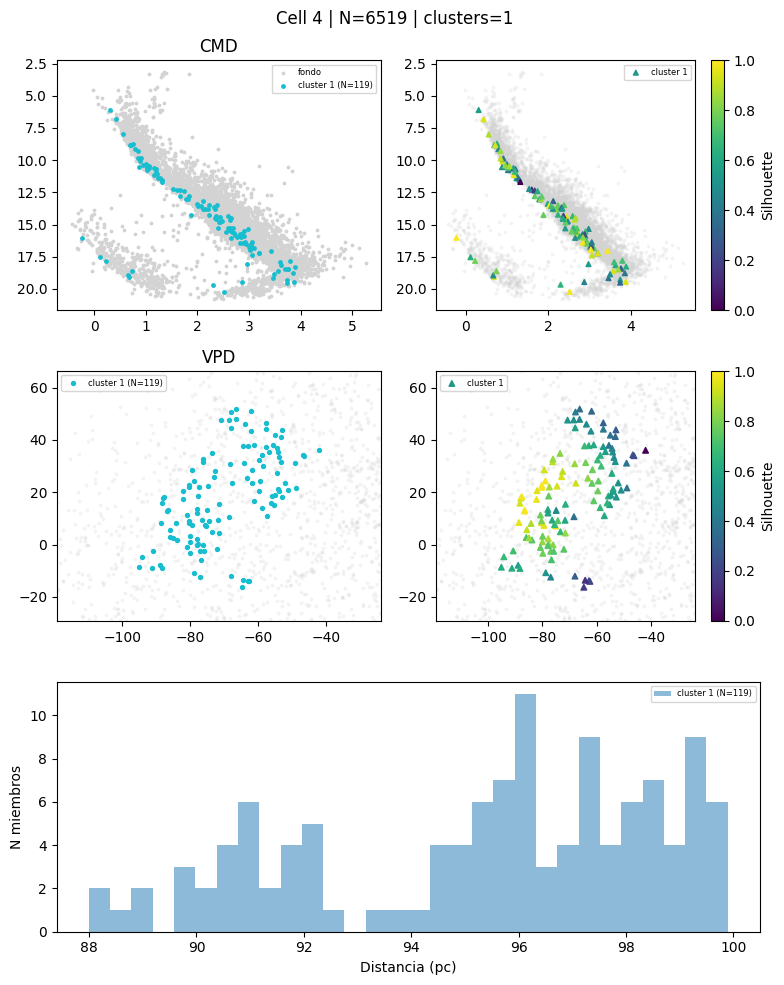

  6%|▋         | 4/64 [00:06<01:50,  1.84s/it]


Cell 5
N estrellas: 6638
N clusters encontrados: 2


  8%|▊         | 5/64 [00:07<01:39,  1.68s/it]

[TAMAÑO] Cluster 0 eliminado | N=2483 | Δd=42.91 pc
[TAMAÑO] Cluster 1 eliminado | N=83 | Δd=17.99 pc
Todos los clusters eliminados tras cortes

Cell 6
N estrellas: 6059
N clusters encontrados: 2


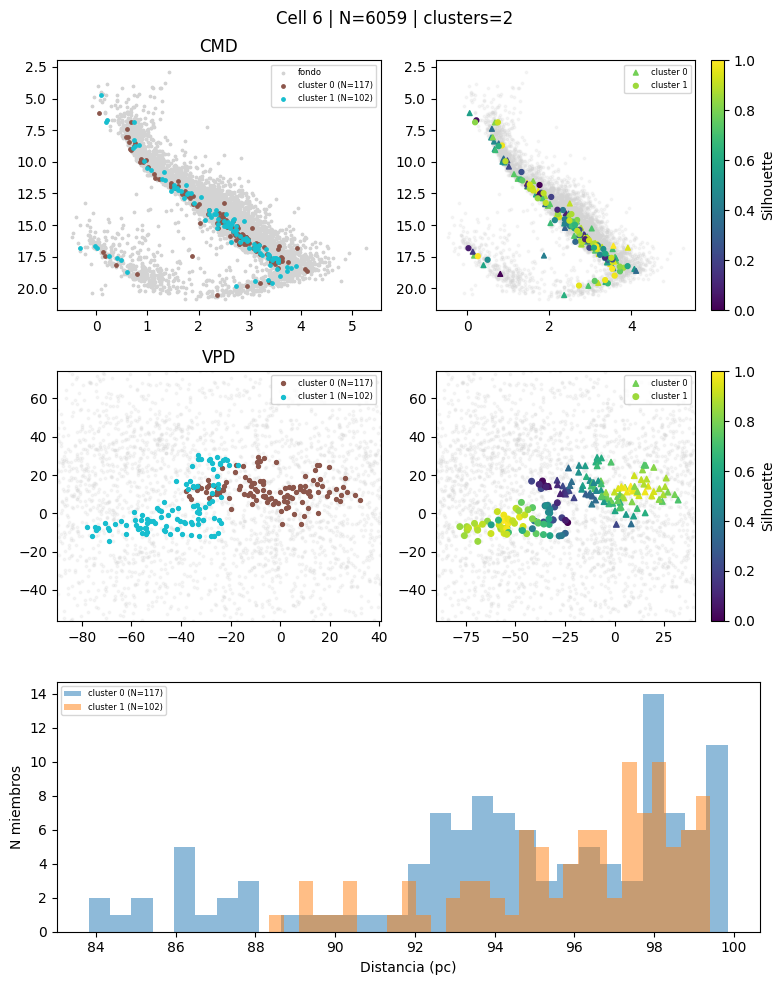

  9%|▉         | 6/64 [00:10<01:59,  2.06s/it]


Cell 7
N estrellas: 4307
N clusters encontrados: 2


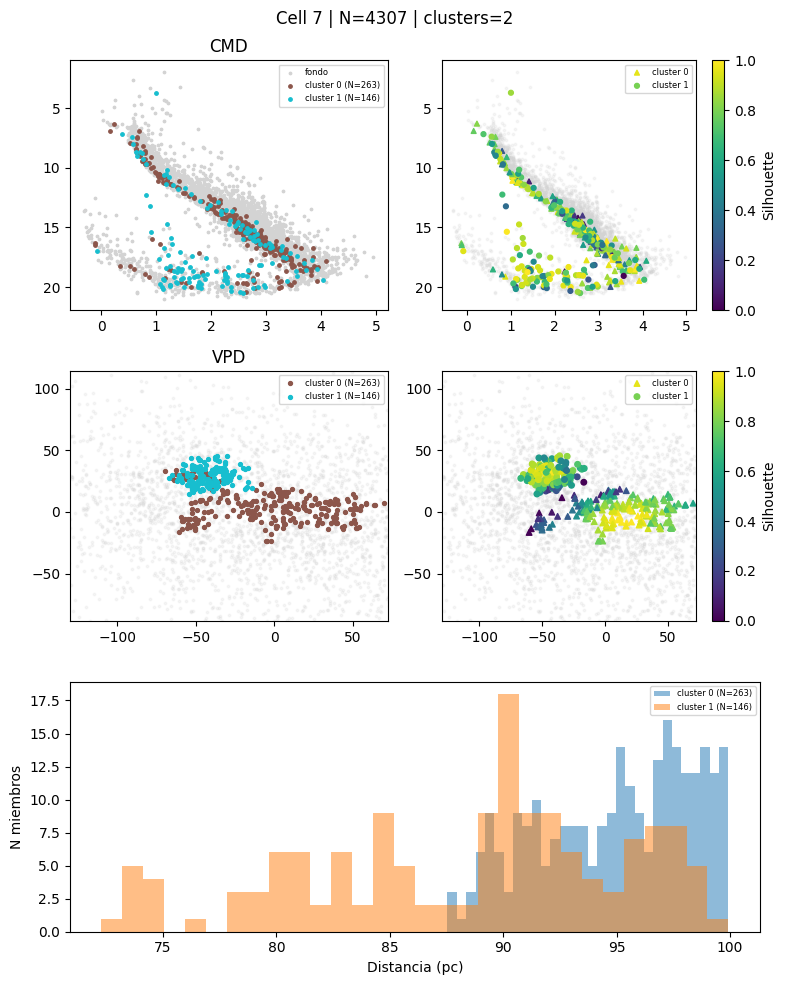

 11%|█         | 7/64 [00:12<01:57,  2.07s/it]


Cell 8
N estrellas: 1434
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 9
N estrellas: 1391
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 10
N estrellas: 3863
N clusters encontrados: 2


 16%|█▌        | 10/64 [00:13<00:53,  1.01it/s]

[TAMAÑO] Cluster 1 eliminado | N=61 | Δd=22.27 pc
[EXTENSIÓN] Cluster 0 eliminado | N=967 | Δd=34.86 pc
Todos los clusters eliminados tras cortes

Cell 11
N estrellas: 5981
N clusters encontrados: 2


 17%|█▋        | 11/64 [00:14<00:53,  1.01s/it]

[TAMAÑO] Cluster 0 eliminado | N=2161 | Δd=39.16 pc
[TAMAÑO] Cluster 1 eliminado | N=81 | Δd=16.65 pc
Todos los clusters eliminados tras cortes

Cell 12
N estrellas: 7019
N clusters encontrados: 2


 19%|█▉        | 12/64 [00:16<00:59,  1.15s/it]

[TAMAÑO] Cluster 1 eliminado | N=64 | Δd=10.16 pc
[TENDENCIA] Cluster 0 eliminado | N=396 | Δd=24.25 pc | slope=5.06
Todos los clusters eliminados tras cortes

Cell 13
N estrellas: 5925
N clusters encontrados: 2


 20%|██        | 13/64 [00:17<00:59,  1.16s/it]

[TAMAÑO] Cluster 1 eliminado | N=71 | Δd=11.79 pc
[TENDENCIA] Cluster 0 eliminado | N=1002 | Δd=24.90 pc | slope=16.83
Todos los clusters eliminados tras cortes

Cell 14
N estrellas: 5760
N clusters encontrados: 3
[TAMAÑO] Cluster 0 eliminado | N=63 | Δd=11.86 pc
[TENDENCIA] Cluster 2 eliminado | N=397 | Δd=28.38 pc | slope=6.44


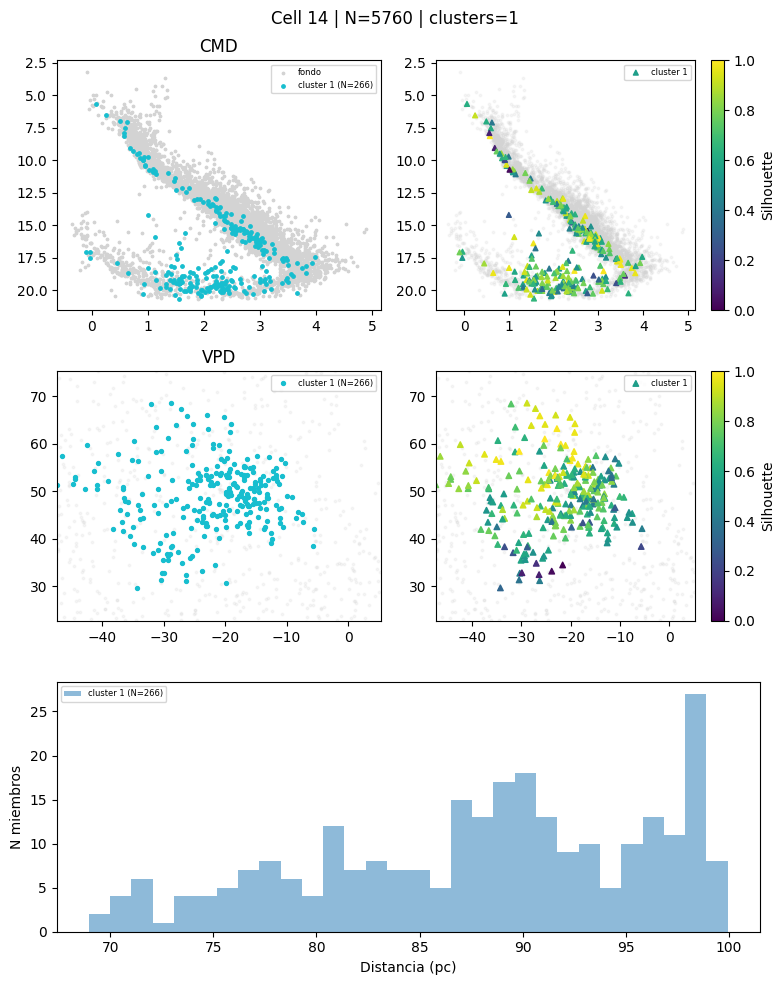

 22%|██▏       | 14/64 [00:19<01:16,  1.54s/it]


Cell 15
N estrellas: 4246
N clusters encontrados: 2


 23%|██▎       | 15/64 [00:20<01:02,  1.27s/it]

[TAMAÑO] Cluster 0 eliminado | N=73 | Δd=14.51 pc
[TENDENCIA] Cluster 1 eliminado | N=686 | Δd=20.46 pc | slope=8.04
Todos los clusters eliminados tras cortes

Cell 16
N estrellas: 1496
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 17
N estrellas: 1470
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 18
N estrellas: 4140


 28%|██▊       | 18/64 [00:20<00:29,  1.54it/s]

N clusters encontrados: 0
Solo ruido, no se grafica

Cell 19
N estrellas: 7175
N clusters encontrados: 2
[TAMAÑO] Cluster 0 eliminado | N=67 | Δd=10.91 pc


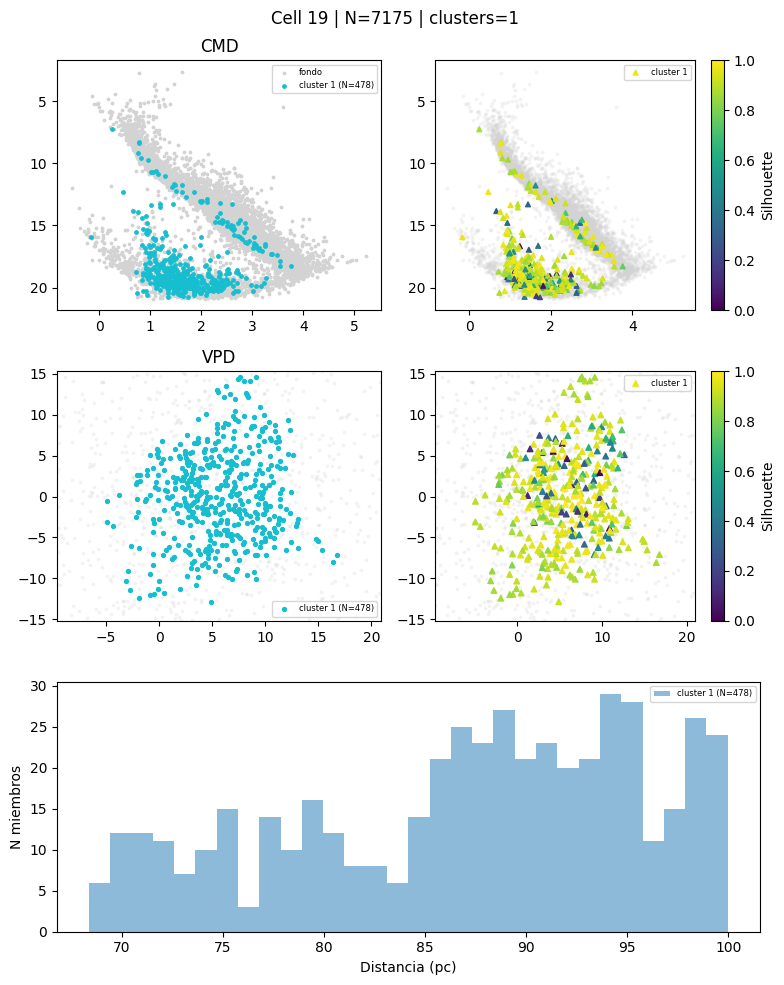

 30%|██▉       | 19/64 [00:24<00:52,  1.17s/it]


Cell 20
N estrellas: 7424
N clusters encontrados: 2
[TENDENCIA] Cluster 1 eliminado | N=560 | Δd=27.22 pc | slope=7.93


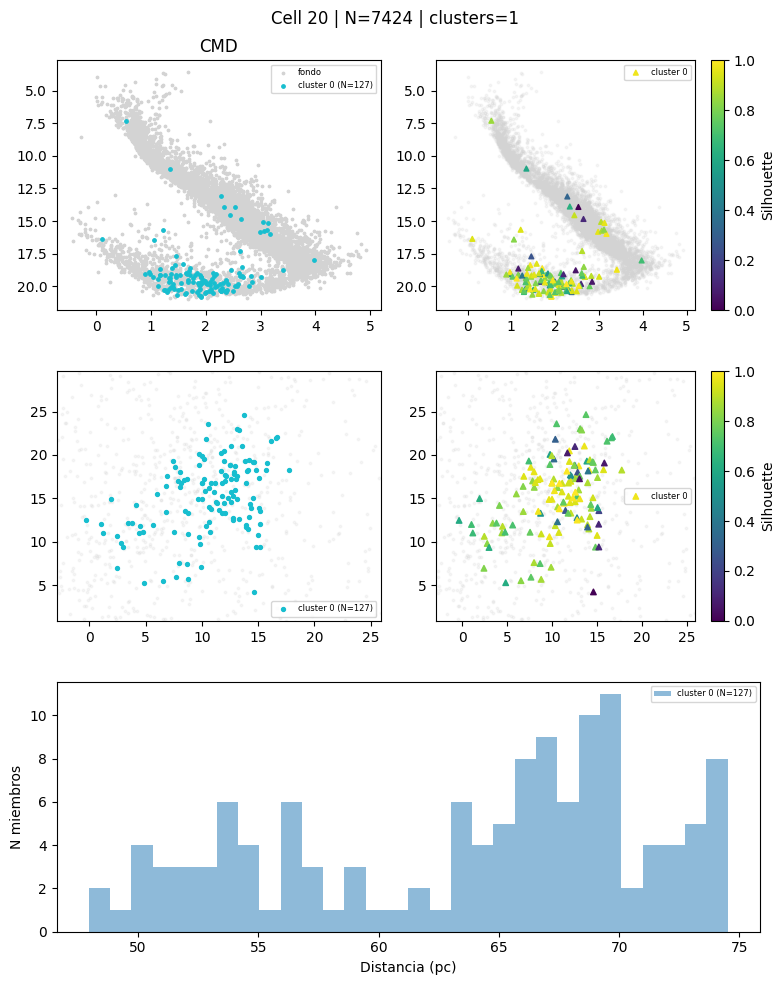

 31%|███▏      | 20/64 [00:27<01:14,  1.70s/it]


Cell 21
N estrellas: 6999
N clusters encontrados: 2


 33%|███▎      | 21/64 [00:29<01:11,  1.67s/it]

[TAMAÑO] Cluster 1 eliminado | N=60 | Δd=12.48 pc
[TENDENCIA] Cluster 0 eliminado | N=515 | Δd=16.47 pc | slope=7.84
Todos los clusters eliminados tras cortes

Cell 22
N estrellas: 5788
N clusters encontrados: 2


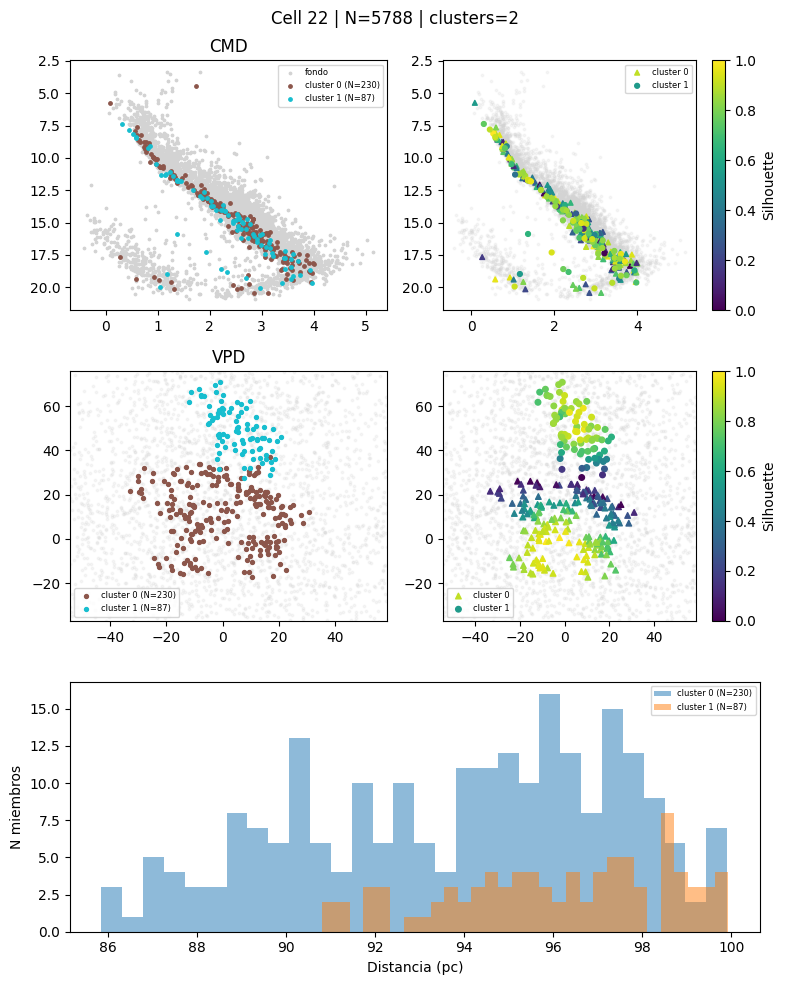

 34%|███▍      | 22/64 [00:31<01:22,  1.95s/it]


Cell 23
N estrellas: 3993
N clusters encontrados: 2


 36%|███▌      | 23/64 [00:32<01:04,  1.57s/it]

[TAMAÑO] Cluster 1 eliminado | N=68 | Δd=17.92 pc
[TENDENCIA] Cluster 0 eliminado | N=819 | Δd=33.04 pc | slope=12.69
Todos los clusters eliminados tras cortes

Cell 24
N estrellas: 1445
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 25
N estrellas: 1517
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 26
N estrellas: 4167
N clusters encontrados: 2


 41%|████      | 26/64 [00:33<00:32,  1.19it/s]

...

[TAMAÑO] Cluster 1 eliminado | N=62 | Δd=13.96 pc
[TENDENCIA] Cluster 0 eliminado | N=538 | Δd=19.77 pc | slope=7.76
Todos los clusters eliminados tras cortes

Cell 29
N estrellas: 6014
N clusters encontrados: 2


 45%|████▌     | 29/64 [00:36<00:37,  1.07s/it]

[TAMAÑO] Cluster 0 eliminado | N=2343 | Δd=45.85 pc
[TAMAÑO] Cluster 1 eliminado | N=70 | Δd=20.81 pc
Todos los clusters eliminados tras cortes

Cell 30
N estrellas: 4880


 47%|████▋     | 30/64 [00:37<00:29,  1.15it/s]

N clusters encontrados: 0
Solo ruido, no se grafica

Cell 31
N estrellas: 3761
N clusters encontrados: 2


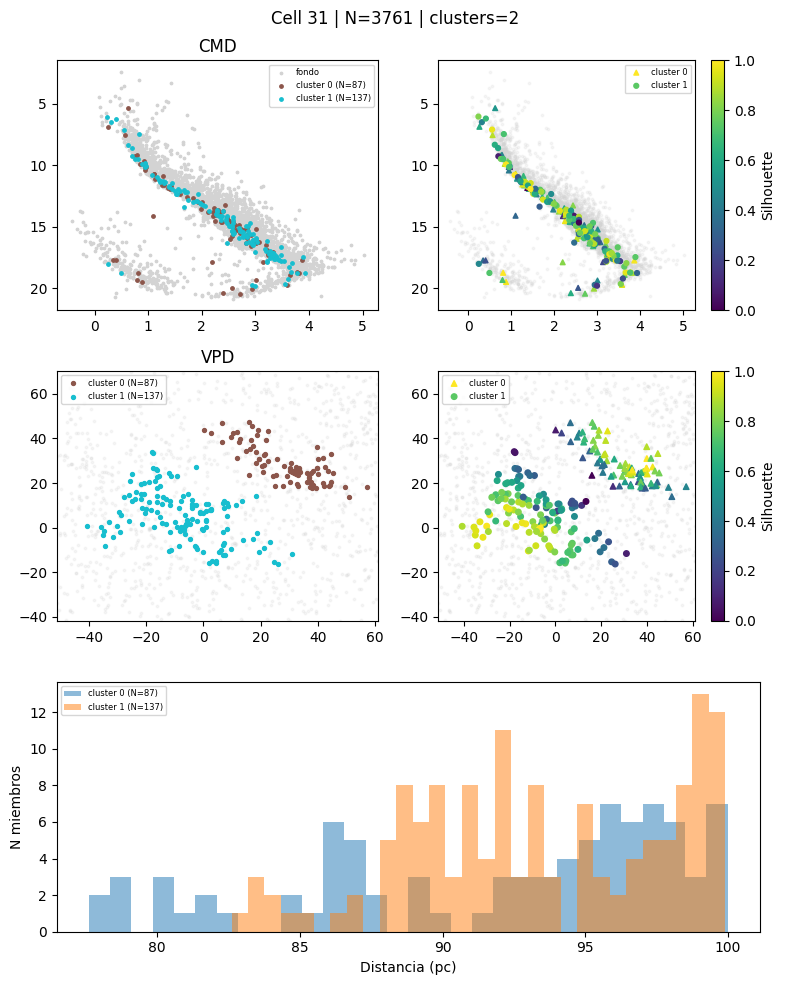

 52%|█████▏    | 33/64 [00:39<00:21,  1.47it/s]


Cell 32
N estrellas: 1373
N clusters encontrados: 2
[EXTENSIÓN] Cluster 0 eliminado | N=216 | Δd=34.29 pc
[EXTENSIÓN] Cluster 1 eliminado | N=85 | Δd=37.19 pc
Todos los clusters eliminados tras cortes

Cell 33
N estrellas: 1514
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 34
N estrellas: 5863
N clusters encontrados: 2
[TAMAÑO] Cluster 1 eliminado | N=1379 | Δd=61.10 pc


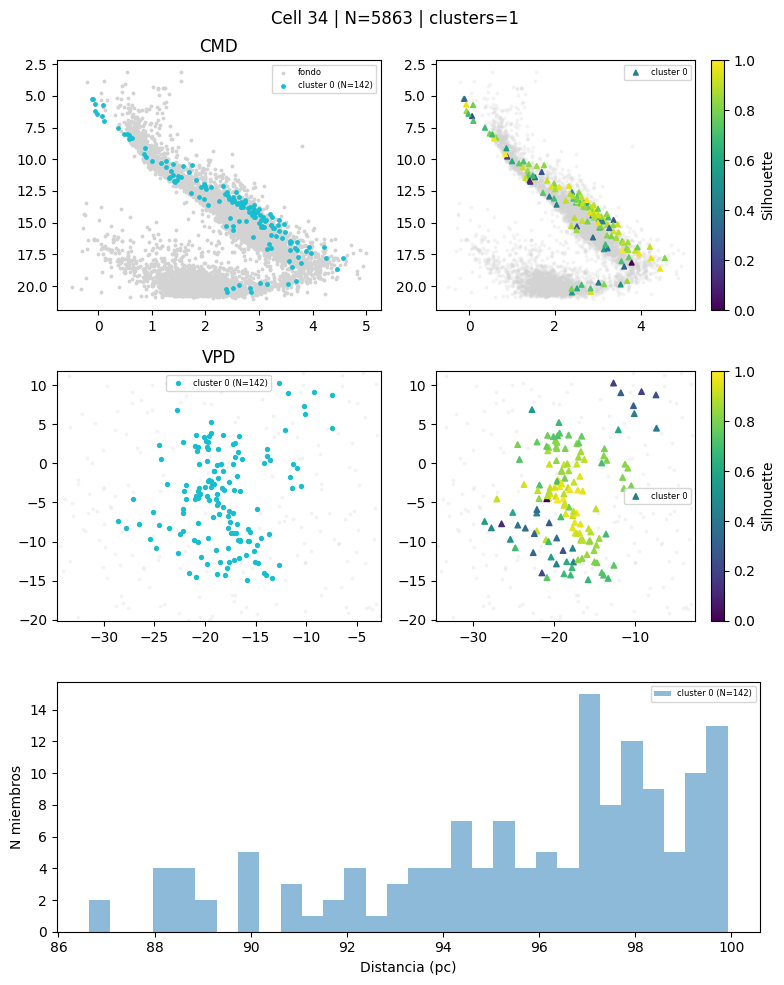

 53%|█████▎    | 34/64 [00:41<00:33,  1.13s/it]


Cell 35
N estrellas: 6379


 55%|█████▍    | 35/64 [00:42<00:27,  1.05it/s]

N clusters encontrados: 0
Solo ruido, no se grafica

Cell 36
N estrellas: 7020
N clusters encontrados: 4


 56%|█████▋    | 36/64 [00:43<00:31,  1.11s/it]

[TAMAÑO] Cluster 0 eliminado | N=76 | Δd=9.11 pc
[TAMAÑO] Cluster 1 eliminado | N=72 | Δd=11.58 pc
[TAMAÑO] Cluster 3 eliminado | N=60 | Δd=11.43 pc
[TENDENCIA] Cluster 2 eliminado | N=346 | Δd=20.29 pc | slope=5.01
Todos los clusters eliminados tras cortes

Cell 37
N estrellas: 5630
N clusters encontrados: 2


 59%|█████▉    | 38/64 [00:45<00:21,  1.21it/s]

[TAMAÑO] Cluster 1 eliminado | N=71 | Δd=17.53 pc
[TENDENCIA] Cluster 0 eliminado | N=915 | Δd=31.21 pc | slope=13.82
Todos los clusters eliminados tras cortes

Cell 38
N estrellas: 4170
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 39
N estrellas: 3935
N clusters encontrados: 3
[TAMAÑO] Cluster 0 eliminado | N=69 | Δd=13.58 pc
[TENDENCIA] Cluster 2 eliminado | N=259 | Δd=21.36 pc | slope=4.23


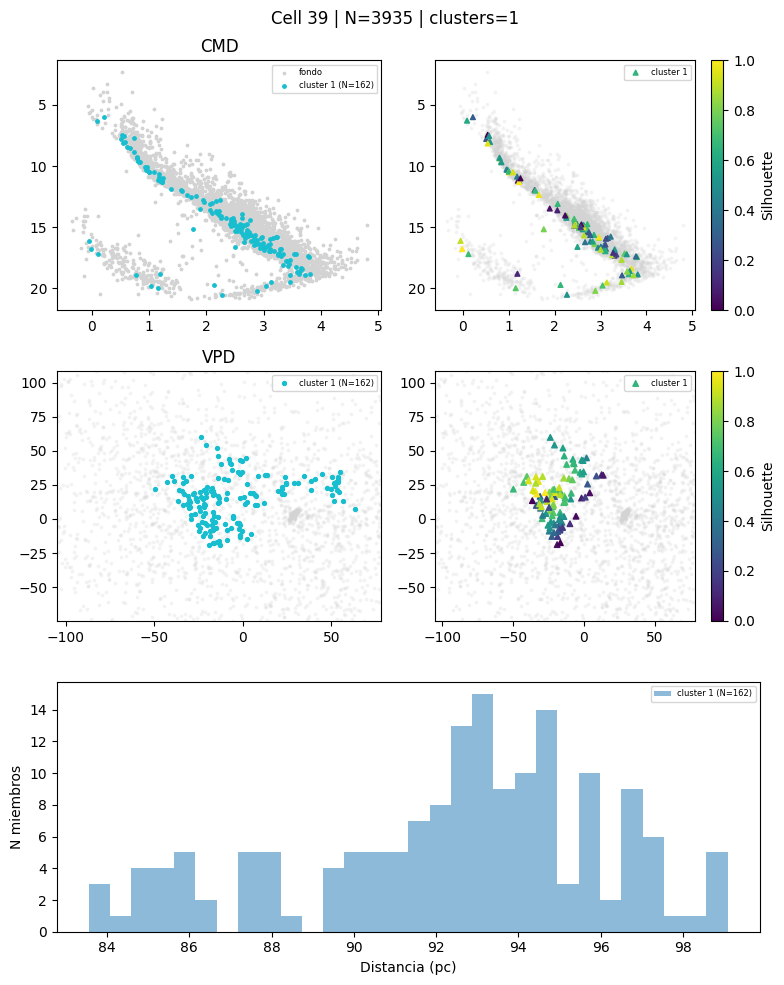

 61%|██████    | 39/64 [00:46<00:27,  1.10s/it]


Cell 40
N estrellas: 1387
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 41
N estrellas: 1607
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 42
N estrellas: 6578
N clusters encontrados: 3
[TAMAÑO] Cluster 0 eliminado | N=61 | Δd=17.42 pc
[TAMAÑO] Cluster 2 eliminado | N=2415 | Δd=61.56 pc


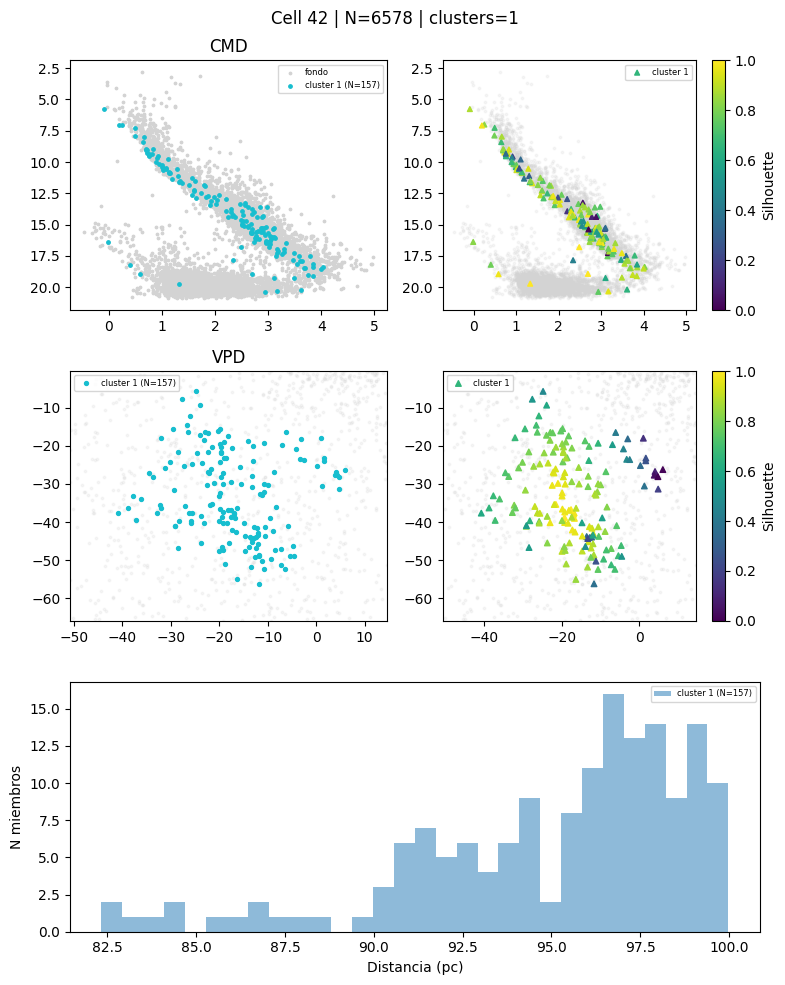

 66%|██████▌   | 42/64 [00:49<00:23,  1.06s/it]


Cell 43
N estrellas: 27671
N clusters encontrados: 4


 67%|██████▋   | 43/64 [01:12<01:55,  5.51s/it]

[TAMAÑO] Cluster 1 eliminado | N=21204 | Δd=77.95 pc
[TAMAÑO] Cluster 2 eliminado | N=72 | Δd=12.41 pc
[EXTENSIÓN] Cluster 0 eliminado | N=87 | Δd=34.84 pc
[TENDENCIA] Cluster 3 eliminado | N=156 | Δd=28.80 pc | slope=3.15
Todos los clusters eliminados tras cortes

Cell 44
N estrellas: 12000
N clusters encontrados: 3
[TENDENCIA] Cluster 1 eliminado | N=531 | Δd=25.68 pc | slope=3.44


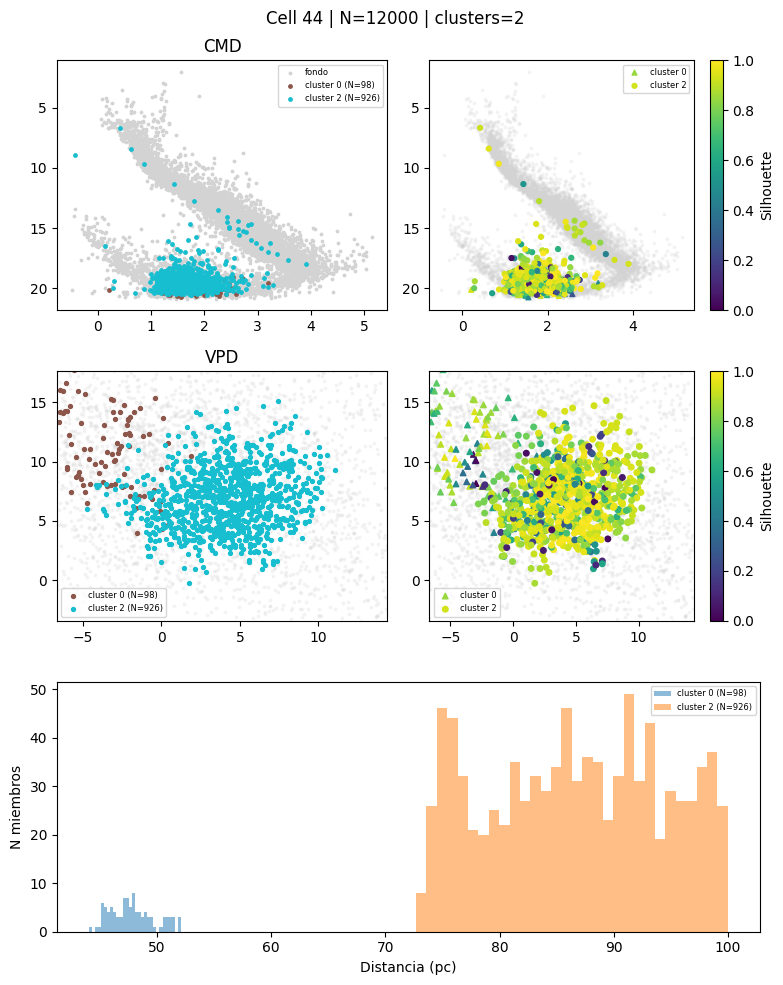

 69%|██████▉   | 44/64 [01:18<01:52,  5.64s/it]


Cell 45
N estrellas: 7295
N clusters encontrados: 2


 70%|███████   | 45/64 [01:20<01:28,  4.66s/it]

[TAMAÑO] Cluster 0 eliminado | N=1280 | Δd=31.68 pc
[TAMAÑO] Cluster 1 eliminado | N=80 | Δd=17.25 pc
Todos los clusters eliminados tras cortes

Cell 46
N estrellas: 6094
N clusters encontrados: 2


 72%|███████▏  | 46/64 [01:21<01:07,  3.76s/it]

[TAMAÑO] Cluster 1 eliminado | N=62 | Δd=12.55 pc
[TENDENCIA] Cluster 0 eliminado | N=380 | Δd=20.96 pc | slope=6.51
Todos los clusters eliminados tras cortes

Cell 47
N estrellas: 3946
N clusters encontrados: 2


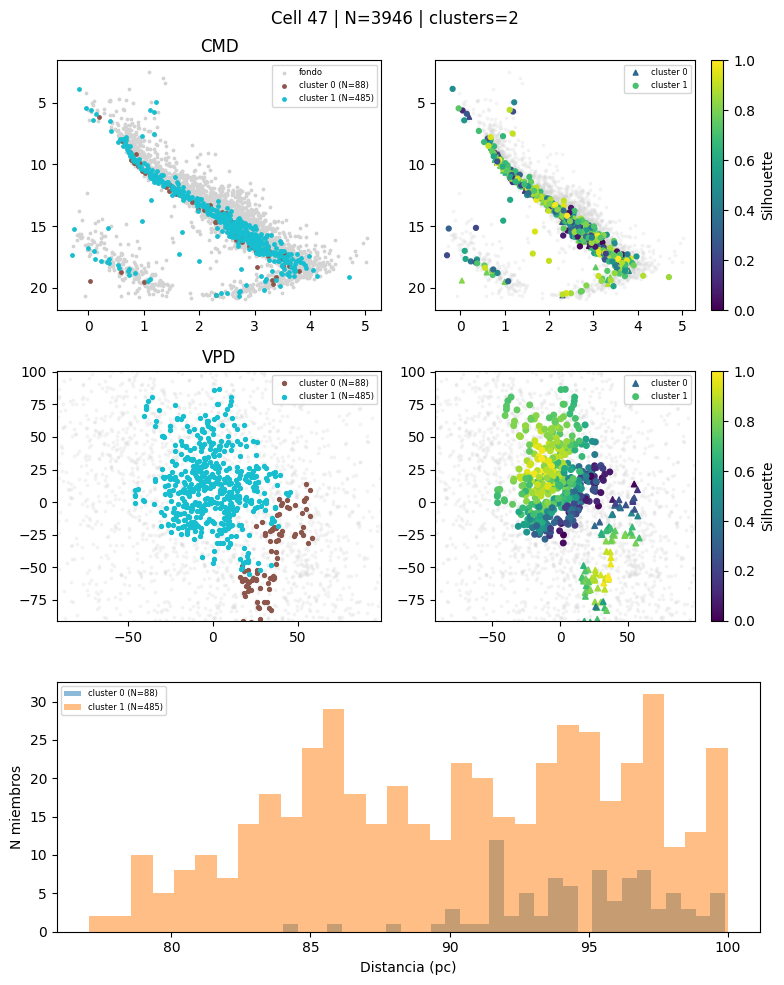

 73%|███████▎  | 47/64 [01:23<00:56,  3.30s/it]


Cell 48
N estrellas: 1491
N clusters encontrados: 2
[TAMAÑO] Cluster 0 eliminado | N=66 | Δd=26.87 pc


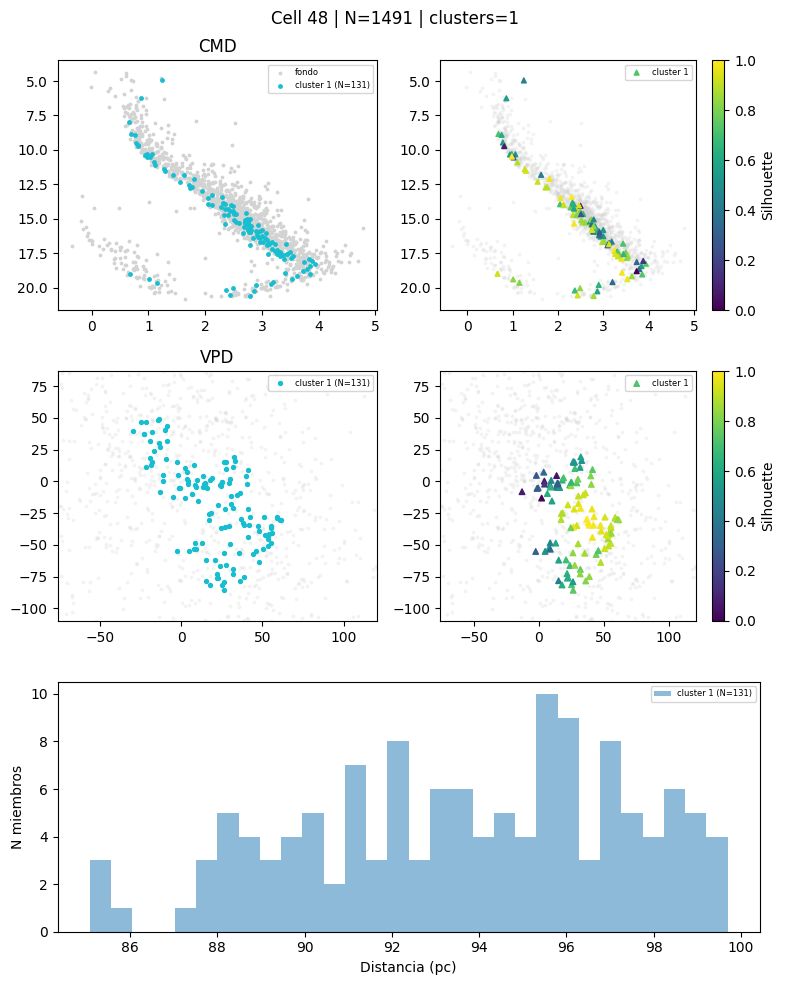

 75%|███████▌  | 48/64 [01:24<00:44,  2.79s/it]


Cell 49
N estrellas: 1543
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 50
N estrellas: 4338
N clusters encontrados: 2


 78%|███████▊  | 50/64 [01:25<00:23,  1.70s/it]

[TAMAÑO] Cluster 1 eliminado | N=61 | Δd=16.10 pc
[EXTENSIÓN] Cluster 0 eliminado | N=1022 | Δd=42.58 pc
Todos los clusters eliminados tras cortes

Cell 51
N estrellas: 12516
N clusters encontrados: 3
[TAMAÑO] Cluster 2 eliminado | N=6186 | Δd=72.78 pc


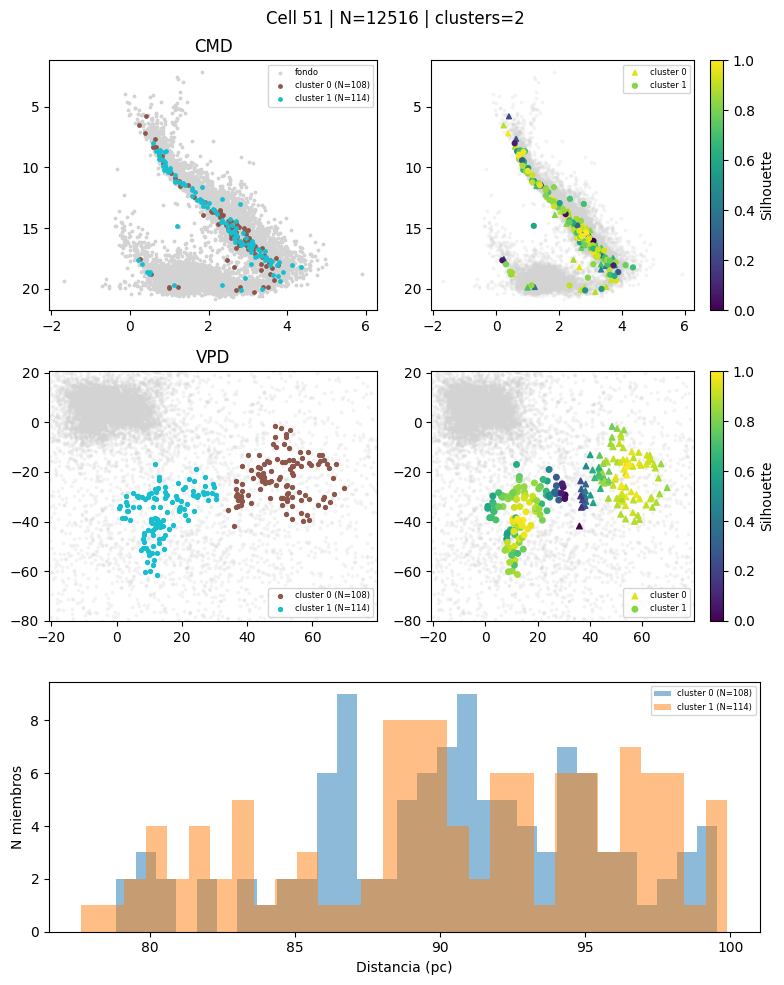

 80%|███████▉  | 51/64 [01:31<00:36,  2.80s/it]


Cell 52
N estrellas: 12219
N clusters encontrados: 3
[TAMAÑO] Cluster 0 eliminado | N=5127 | Δd=71.27 pc
[TAMAÑO] Cluster 1 eliminado | N=76 | Δd=18.55 pc


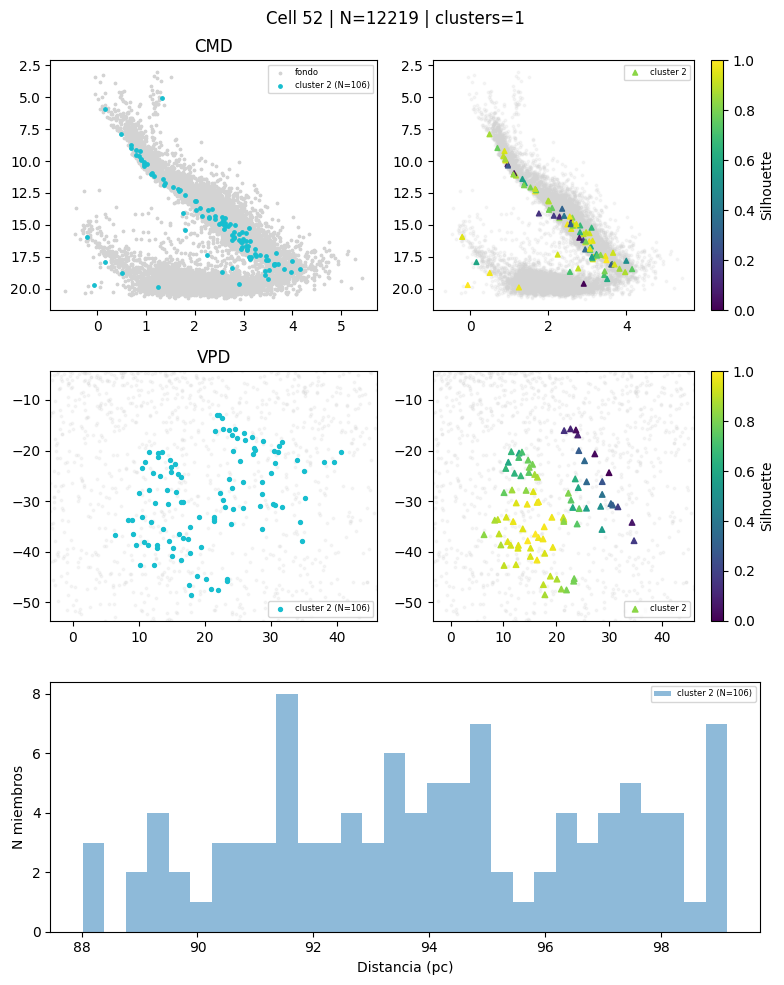

 81%|████████▏ | 52/64 [01:37<00:42,  3.57s/it]


Cell 53
N estrellas: 11638
N clusters encontrados: 3


 83%|████████▎ | 53/64 [01:41<00:39,  3.59s/it]

[TAMAÑO] Cluster 0 eliminado | N=60 | Δd=19.79 pc
[TAMAÑO] Cluster 1 eliminado | N=5333 | Δd=78.02 pc
[TAMAÑO] Cluster 2 eliminado | N=63 | Δd=22.13 pc
Todos los clusters eliminados tras cortes

Cell 54
N estrellas: 9276
N clusters encontrados: 2


 84%|████████▍ | 54/64 [01:43<00:33,  3.32s/it]

...

[TAMAÑO] Cluster 0 eliminado | N=2027 | Δd=46.86 pc
[TAMAÑO] Cluster 1 eliminado | N=60 | Δd=25.75 pc
Todos los clusters eliminados tras cortes

Cell 56
N estrellas: 1421
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 57
N estrellas: 1433
N clusters encontrados: 2
[TAMAÑO] Cluster 0 eliminado | N=83 | Δd=17.28 pc
[TAMAÑO] Cluster 1 eliminado | N=62 | Δd=19.49 pc
Todos los clusters eliminados tras cortes

Cell 58
N estrellas: 4040
N clusters encontrados: 2


 91%|█████████ | 58/64 [01:45<00:07,  1.21s/it]

[TAMAÑO] Cluster 1 eliminado | N=67 | Δd=21.68 pc
[EXTENSIÓN] Cluster 0 eliminado | N=788 | Δd=35.12 pc
Todos los clusters eliminados tras cortes

Cell 59
N estrellas: 5892
N clusters encontrados: 2


 92%|█████████▏| 59/64 [01:46<00:05,  1.18s/it]

[TAMAÑO] Cluster 0 eliminado | N=65 | Δd=16.86 pc
[TAMAÑO] Cluster 1 eliminado | N=1411 | Δd=36.40 pc
Todos los clusters eliminados tras cortes

Cell 60
N estrellas: 6982
N clusters encontrados: 2


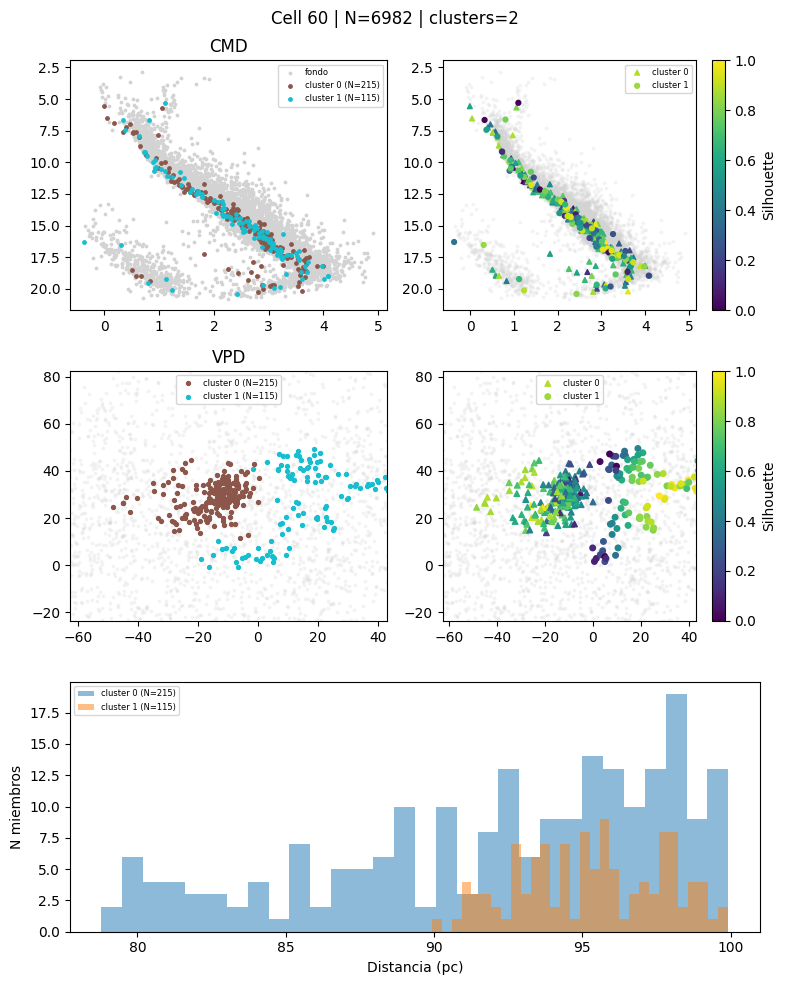

 94%|█████████▍| 60/64 [01:49<00:07,  1.75s/it]


Cell 61
N estrellas: 7011
N clusters encontrados: 2


 95%|█████████▌| 61/64 [01:50<00:05,  1.67s/it]

[TAMAÑO] Cluster 0 eliminado | N=2969 | Δd=53.63 pc
[TAMAÑO] Cluster 1 eliminado | N=68 | Δd=24.29 pc
Todos los clusters eliminados tras cortes

Cell 62
N estrellas: 6341
N clusters encontrados: 2
[TENDENCIA] Cluster 0 eliminado | N=658 | Δd=20.34 pc | slope=9.26


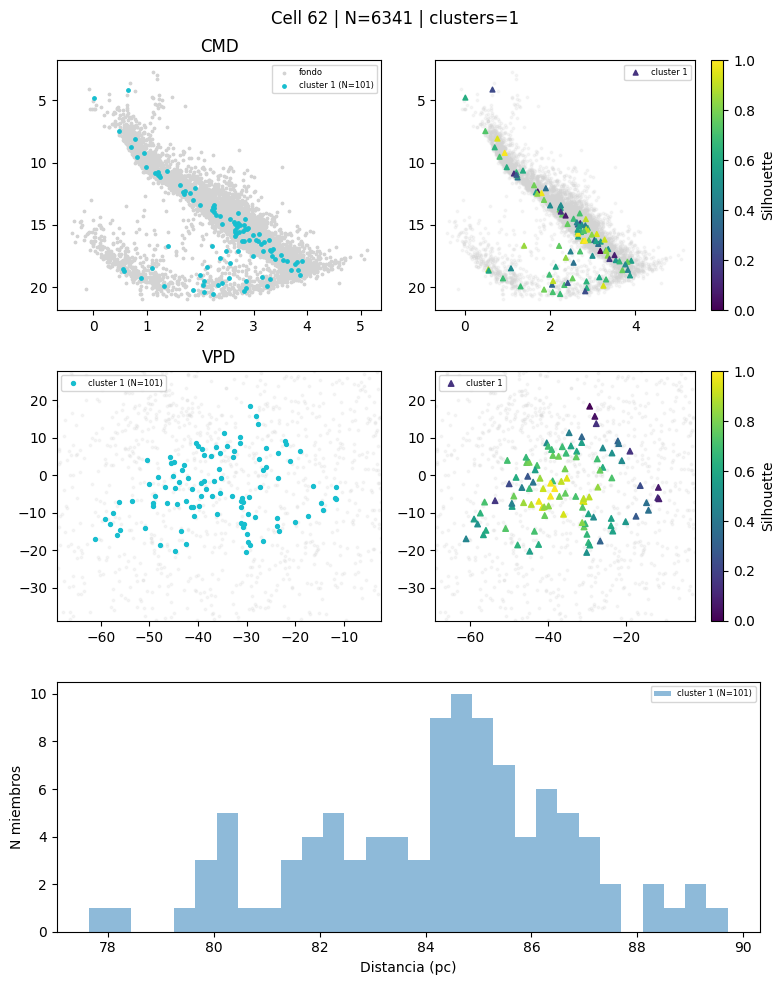

 97%|█████████▋| 62/64 [01:53<00:04,  2.01s/it]


Cell 63
N estrellas: 4381
N clusters encontrados: 2


100%|██████████| 64/64 [01:54<00:00,  1.79s/it]

[TAMAÑO] Cluster 1 eliminado | N=73 | Δd=13.33 pc
[TENDENCIA] Cluster 0 eliminado | N=820 | Δd=28.61 pc | slope=9.62
Todos los clusters eliminados tras cortes

Cell 64
N estrellas: 1520
N clusters encontrados: 0
Solo ruido, no se grafica

CHECK GLOBAL
Total entrada (sumado): 342356
Total procesado (sumado): 342356
Total final filas: 342356
Total estrellas únicas procesadas: 342356
Índices únicos en df_final: 342356


In [5]:
for cell_id in tqdm(sorted(df["cell_id"].unique())):

    df_cell = df[df["cell_id"] == cell_id].copy()

    n_stars = len(df_cell)
    total_input += n_stars
    unique_ids.update(df_cell.index)

    print("\n==============================")
    print(f"Cell {cell_id}")
    print(f"N estrellas: {n_stars}")

    if n_stars < 30:
        print("Menos de 30 estrellas en total, se omite")
        continue

    # preparar datos
    features = df_cell[['pmra','pmdec','dist_pc']]
    data_scaled = RobustScaler().fit_transform(features)

    # HDBSCAN
    hd = HDBSCAN(min_cluster_size=60,min_samples=5,metric='euclidean').fit(data_scaled)
    labels = hd.labels_
    df_cell["label_hb"] = labels
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    print(f"N clusters encontrados: {n_clusters}")
    total_processed += len(df_cell)
    if n_clusters == 0:
        print("Solo ruido, no se grafica")
        results.append(df_cell)
        continue

    # silhouette
    if n_clusters > 1:
        sil = silhouette_samples(data_scaled, labels)
        df_cell["silhouette"] = sil
    else:
        df_cell["silhouette"] = np.nan

    # centrar VPD
    df_cell["pmra_rel"] = df_cell["pmra"] - df_cell["pmra"].median()
    df_cell["pmdec_rel"] = df_cell["pmdec"] - df_cell["pmdec"].median()

    # tamaños de clusters
    cluster_sizes = {lab: np.sum(df_cell["label_hb"] == lab) for lab in unique_labels if lab != -1}

    # CORTE POR TAMAÑO
    for lab in list(cluster_sizes.keys()):
        size = cluster_sizes[lab]
        if size > 1100:
            cond = df_cell["label_hb"] == lab
            extension = df_cell.loc[cond, "dist_pc"].max() - df_cell.loc[cond, "dist_pc"].min()
            print(f"[TAMAÑO] Cluster {lab} eliminado | N={size} | Δd={extension:.2f} pc")
            df_cell.loc[cond, "label_hb"] = -1
            del cluster_sizes[lab]

        elif size < 85:    
            cond = df_cell["label_hb"] == lab
            extension = df_cell.loc[cond, "dist_pc"].max() - df_cell.loc[cond, "dist_pc"].min()
            print(f"[TAMAÑO] Cluster {lab} eliminado | N={size} | Δd={extension:.2f} pc")
            df_cell.loc[cond, "label_hb"] = -1
            del cluster_sizes[lab]

    # CORTE EN EXTENSIÓN 
    for lab in list(cluster_sizes.keys()):
        cond = df_cell["label_hb"] == lab
        dist_cluster = df_cell.loc[cond, "dist_pc"]
        extension = dist_cluster.max() - dist_cluster.min()
        if extension > 34:
            print(f"[EXTENSIÓN] Cluster {lab} eliminado | N={cluster_sizes[lab]} | Δd={extension:.2f} pc")
            # Re-etiquetar como ruido
            df_cell.loc[cond, "label_hb"] = -1
            # eliminar del diccionario
            del cluster_sizes[lab]

    # CORTE POR MONOTONÍA
    for lab in list(cluster_sizes.keys()):
        cond = df_cell["label_hb"] == lab
        dist_cluster = df_cell.loc[cond, "dist_pc"]
        counts, _ = np.histogram(dist_cluster, bins=12)

        # pendiente global
        x = np.arange(len(counts))
        coef = np.polyfit(x, counts, 1)[0]

        # fracción de incrementos positivos
        diffs = np.diff(counts)
        frac_positive = np.sum(diffs >= 0) / len(diffs)
        slope_threshold = 2.5   
        frac_threshold = 0.65   
        is_bad_distribution = (coef > slope_threshold) and (frac_positive > frac_threshold)

        if is_bad_distribution:
            extension = dist_cluster.max() - dist_cluster.min()
            print(f"[TENDENCIA] Cluster {lab} eliminado | N={cluster_sizes[lab]} | Δd={extension:.2f} pc | slope={coef:.2f}")
            df_cell.loc[cond, "label_hb"] = -1
            del cluster_sizes[lab]
    
    # Recalcular clusters
    n_clusters = len(cluster_sizes)
    if n_clusters == 0:
        print("Todos los clusters eliminados tras cortes")
        results.append(df_cell)
        continue

    # RECONSTRUIR CLUSTERS FINALES
    final_labels = np.unique(df_cell["label_hb"])
    final_labels = final_labels[final_labels != -1]
    cluster_sizes = {lab: np.sum(df_cell["label_hb"] == lab)for lab in final_labels}

    cluster_cmaps = ["viridis","plasma","cividis","coolwarm","magma","Blues","Reds","Greens"]
    markers = ['^', 'o', 's', 'D', 'v', 'P', '*', 'X']

    # CENTRO Y ESCALA VPD 
    mask_clusters = df_cell["label_hb"].isin(cluster_sizes.keys())
    if np.sum(mask_clusters) > 0:
        pmra_center = df_cell.loc[mask_clusters, "pmra_rel"].median()
        pmdec_center = df_cell.loc[mask_clusters, "pmdec_rel"].median()
        r = np.sqrt((df_cell.loc[mask_clusters, "pmra_rel"] - pmra_center)**2 +(df_cell.loc[mask_clusters, "pmdec_rel"] - pmdec_center)**2)
        r_max = np.percentile(r, 90) * 1.5
    else:
        pmra_center, pmdec_center, r_max = 0, 0, 5

    # colores 
    unique_labels = np.unique(df_cell["label_hb"])
    cmap = plt.cm.get_cmap('tab10', len(unique_labels))
    color_map = {lab: ('lightgray' if lab == -1 else cmap(i))for i, lab in enumerate(unique_labels)}

    # FIGURA
    fig = plt.figure(figsize=(8,10))
    gs = fig.add_gridspec(3,2)
    ax_cmd = fig.add_subplot(gs[0,0])
    ax_cmd_sil = fig.add_subplot(gs[0,1])
    ax_vpd = fig.add_subplot(gs[1,0])
    ax_vpd_sil = fig.add_subplot(gs[1,1])
    ax_hist = fig.add_subplot(gs[2,:])

    # CMD fondo
    ax_cmd.scatter(df_cell["bp_rp"], df_cell["phot_g_mean_mag"],c='lightgray', s=3, label="fondo")
    for lab in cluster_sizes:
        cond = df_cell["label_hb"] == lab
        ax_cmd.scatter(df_cell["bp_rp"][cond], df_cell["phot_g_mean_mag"][cond],s=6,
            color=color_map[lab], label=f"cluster {lab} (N={cluster_sizes[lab]})")

    ax_cmd.invert_yaxis()
    ax_cmd.set_title("CMD")
    ax_cmd.legend(fontsize=6)

    # CMD silueta
    sil_threshold = 0.1
    mask_bad = (df_cell["silhouette"] < sil_threshold) | (df_cell["label_hb"] == -1)
    ax_cmd_sil.scatter(df_cell["bp_rp"][mask_bad],df_cell["phot_g_mean_mag"][mask_bad],c='lightgray',s=3,alpha=0.2)
    ax_cmd_sil.invert_yaxis()

    # clusters individualmente
    for i, lab in enumerate(cluster_sizes):
        cond = (df_cell["label_hb"] == lab) & (df_cell["silhouette"] >= sil_threshold)
        sil_vals = df_cell.loc[cond, "silhouette"]
        if len(sil_vals) == 0:
            continue
        # normalización local
        s_min, s_max = sil_vals.min(), sil_vals.max()
        if s_max > s_min:
            sil_norm = (sil_vals - s_min) / (s_max - s_min)
        else:
            sil_norm = np.zeros_like(sil_vals)

        marker = markers[i % len(markers)]
        sc1 = ax_cmd_sil.scatter(df_cell["bp_rp"][cond],df_cell["phot_g_mean_mag"][cond],c=sil_norm, cmap = 'viridis', 
                           marker=marker,s=12,label=f"cluster {lab}")
        
    cbar = plt.colorbar(sc1, ax=ax_cmd_sil)
    cbar.set_label("Silhouette")
    ax_cmd_sil.legend(fontsize = 6)

    # VPD fondo
    ax_vpd.scatter(df_cell["pmra_rel"],df_cell["pmdec_rel"],c='lightgray',s=3,alpha=0.2)

    for lab in cluster_sizes:
        cond = df_cell["label_hb"] == lab
        ax_vpd.scatter(df_cell["pmra_rel"][cond],df_cell["pmdec_rel"][cond],
            s=8,color=color_map[lab],label=f"cluster {lab} (N={cluster_sizes[lab]})")

    # zoom
    ax_vpd.set_xlim(pmra_center - r_max, pmra_center + r_max)
    ax_vpd.set_ylim(pmdec_center - r_max, pmdec_center + r_max)
    ax_vpd.set_title("VPD")
    ax_vpd.legend(fontsize=6)

    # VPD SILUETA 
    sil_threshold = 0.1
    ax_vpd_sil.scatter(df_cell["pmra_rel"][mask_bad],df_cell["pmdec_rel"][mask_bad],c='lightgray',s=3,alpha=0.2)

    for i, lab in enumerate(cluster_sizes):
        cond = (df_cell["label_hb"] == lab) & (df_cell["silhouette"] >= sil_threshold)
        sil_vals = df_cell.loc[cond, "silhouette"]
        if len(sil_vals) == 0:
            continue
        s_min, s_max = sil_vals.min(), sil_vals.max()
        if s_max > s_min:
            sil_norm = (sil_vals - s_min) / (s_max - s_min)
        else:
            sil_norm = np.zeros_like(sil_vals)
        marker = markers[i % len(markers)]

        ax_vpd_sil.scatter(df_cell["pmra_rel"][cond],df_cell["pmdec_rel"][cond],c=sil_norm,
            cmap='viridis',marker=marker,s=16,label=f"cluster {lab}")
    cbar2 = plt.colorbar(sc1, ax=ax_vpd_sil)
    cbar2.set_label("Silhouette")
    ax_vpd_sil.legend(fontsize = 6)

    # mismo zoom
    ax_vpd_sil.set_xlim(pmra_center - r_max, pmra_center + r_max)
    ax_vpd_sil.set_ylim(pmdec_center - r_max, pmdec_center + r_max)

    # HISTOGRAMA 
    for lab in cluster_sizes:
        cond = df_cell["label_hb"] == lab

        ax_hist.hist( df_cell["dist_pc"][cond],bins=30, alpha=0.5,
                     label=f"cluster {lab} (N={cluster_sizes[lab]})")

    #ax_hist.set_yscale("log")
    ax_hist.set_xlabel("Distancia (pc)")
    ax_hist.set_ylabel("N miembros")
    ax_hist.legend(fontsize=6)

    plt.suptitle(f"Cell {cell_id} | N={n_stars} | clusters={n_clusters}")
    plt.tight_layout()
    plt.show()
    results.append(df_cell)

df_final = pd.concat(results)

print("\n==============================")
print("CHECK GLOBAL")
print(f"Total entrada (sumado): {total_input}")
print(f"Total procesado (sumado): {total_processed}")
print(f"Total final filas: {len(df_final)}")
print(f"Total estrellas únicas procesadas: {len(unique_ids)}")
print(f"Índices únicos en df_final: {df_final.index.nunique()}")